Automobile Insurance Fraud Detection — Python, Scikit-learn, Streamlit

Built a machine learning classification system to identify potentially fraudulent automobile insurance claims using structured claim and customer data.

In [52]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import os 
import streamlit as st
import sklearn 


In [53]:
df = pd.read_csv(r"C:\Users\Martino VIGNIGBE\OneDrive\DATA SCIENCE PROJECT MARTINO\insurance-fraud-detection\data\insurance_claims.csv")

In [54]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [55]:
df.shape

(1000, 40)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [57]:
# Drop the column only if it exists
df.drop(columns=['_c39'], inplace=True, errors='ignore')

df.shape


(1000, 39)

In [58]:
df.isnull().sum()


months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [59]:
df['authorities_contacted'].value_counts(dropna=False)

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
NaN           91
Name: count, dtype: int64

In [60]:
df["authorities_contacted"] = df["authorities_contacted"].fillna("Other")

In [61]:
df['authorities_contacted'].value_counts(dropna=False)

authorities_contacted
Police       292
Other        289
Fire         223
Ambulance    196
Name: count, dtype: int64

In [62]:
df["authorities_contacted"].value_counts()

authorities_contacted
Police       292
Other        289
Fire         223
Ambulance    196
Name: count, dtype: int64

In [63]:
df["authorities_contacted"].map(repr).unique()

array(["'Police'", "'Other'", "'Fire'", "'Ambulance'"], dtype=object)

In [64]:
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'], errors='coerce')

df['incident_date'] = pd.to_datetime(df['incident_date'], errors='coerce')

df['auto_year'] = pd.to_datetime(
    df['auto_year'], format='%Y', errors='coerce'
).dt.year.astype('Int64')

df['collision_type'].replace('?', 'Unknown collision', inplace=True)

df['property_damage'].replace('?', 'Undefined', inplace=True) 

df['police_report_available'].replace('?', 'Unknown', inplace=True)

C:\Users\Martino VIGNIGBE\AppData\Local\Temp\ipykernel_38788\1875445814.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'], errors='coerce')
C:\Users\Martino VIGNIGBE\AppData\Local\Temp\ipykernel_38788\1875445814.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['incident_date'] = pd.to_datetime(df['incident_date'], errors='coerce')


In [65]:
df.describe()

,months_as_customer,age,policy_number,policy_bind_date,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_date,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.0
mean,203.954000,38.948000,546238.648000,2002-02-08 04:40:47.999999872,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,2015-01-30 08:02:24,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103
min,0.000000,19.000000,100804.000000,1990-01-08 00:00:00,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,2015-01-01 00:00:00,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.0
25%,115.750000,32.000000,335980.250000,1995-09-19 00:00:00,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,2015-01-15 00:00:00,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.0
50%,199.500000,38.000000,533135.000000,2002-04-01 12:00:00,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,2015-01-31 00:00:00,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.0
75%,276.250000,44.000000,759099.750000,2008-04-21 12:00:00,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,2015-02-15 00:00:00,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.0
max,479.000000,64.000000,999435.000000,2015-02-22 00:00:00,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,2015-03-01 00:00:00,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.0
std,115.113174,9.140287,257063.005276,NaN,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,NaN,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

In [67]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns

['months_as_customer',
 'age',
 'policy_number',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital-gains',
 'capital-loss',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_year']

In [68]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()
categorical_columns

['policy_state',
 'policy_csl',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'auto_model',
 'fraud_reported']

In [69]:
#les donnees numeriques
num_df = df.select_dtypes(include=np.number)
num_df.head()

num_df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.0
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.0
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.0
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.0
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.0


In [70]:
cat_df = df.select_dtypes(include='object')
cat_df.head()   


,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
0,OH,250/500,MALE,MD,craft-repair,sleeping,husband,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,YES,YES,Saab,92x,Y
1,IN,250/500,MALE,MD,machine-op-inspct,reading,other-relative,Vehicle Theft,Unknown collision,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,Undefined,Unknown,Mercedes,E400,Y
2,OH,100/300,FEMALE,PhD,sales,board-games,own-child,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,NO,NO,Dodge,RAM,N
3,IL,250/500,FEMALE,PhD,armed-forces,board-games,unmarried,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,Undefined,NO,Chevrolet,Tahoe,Y
4,IL,500/1000,MALE,Associate,sales,board-games,unmarried,Vehicle Theft,Unknown collision,Minor Damage,Other,NY,Arlington,3041 3rd Ave,NO,NO,Accura,RSX,N


In [71]:
res_df= df.select_dtypes(include='datetime64')

In [72]:
res_df.head()

,policy_bind_date,incident_date
0,2014-10-17,2015-01-25
1,2006-06-27,2015-01-21
2,2000-09-06,2015-02-22
3,1990-05-25,2015-01-10
4,2014-06-06,2015-02-17


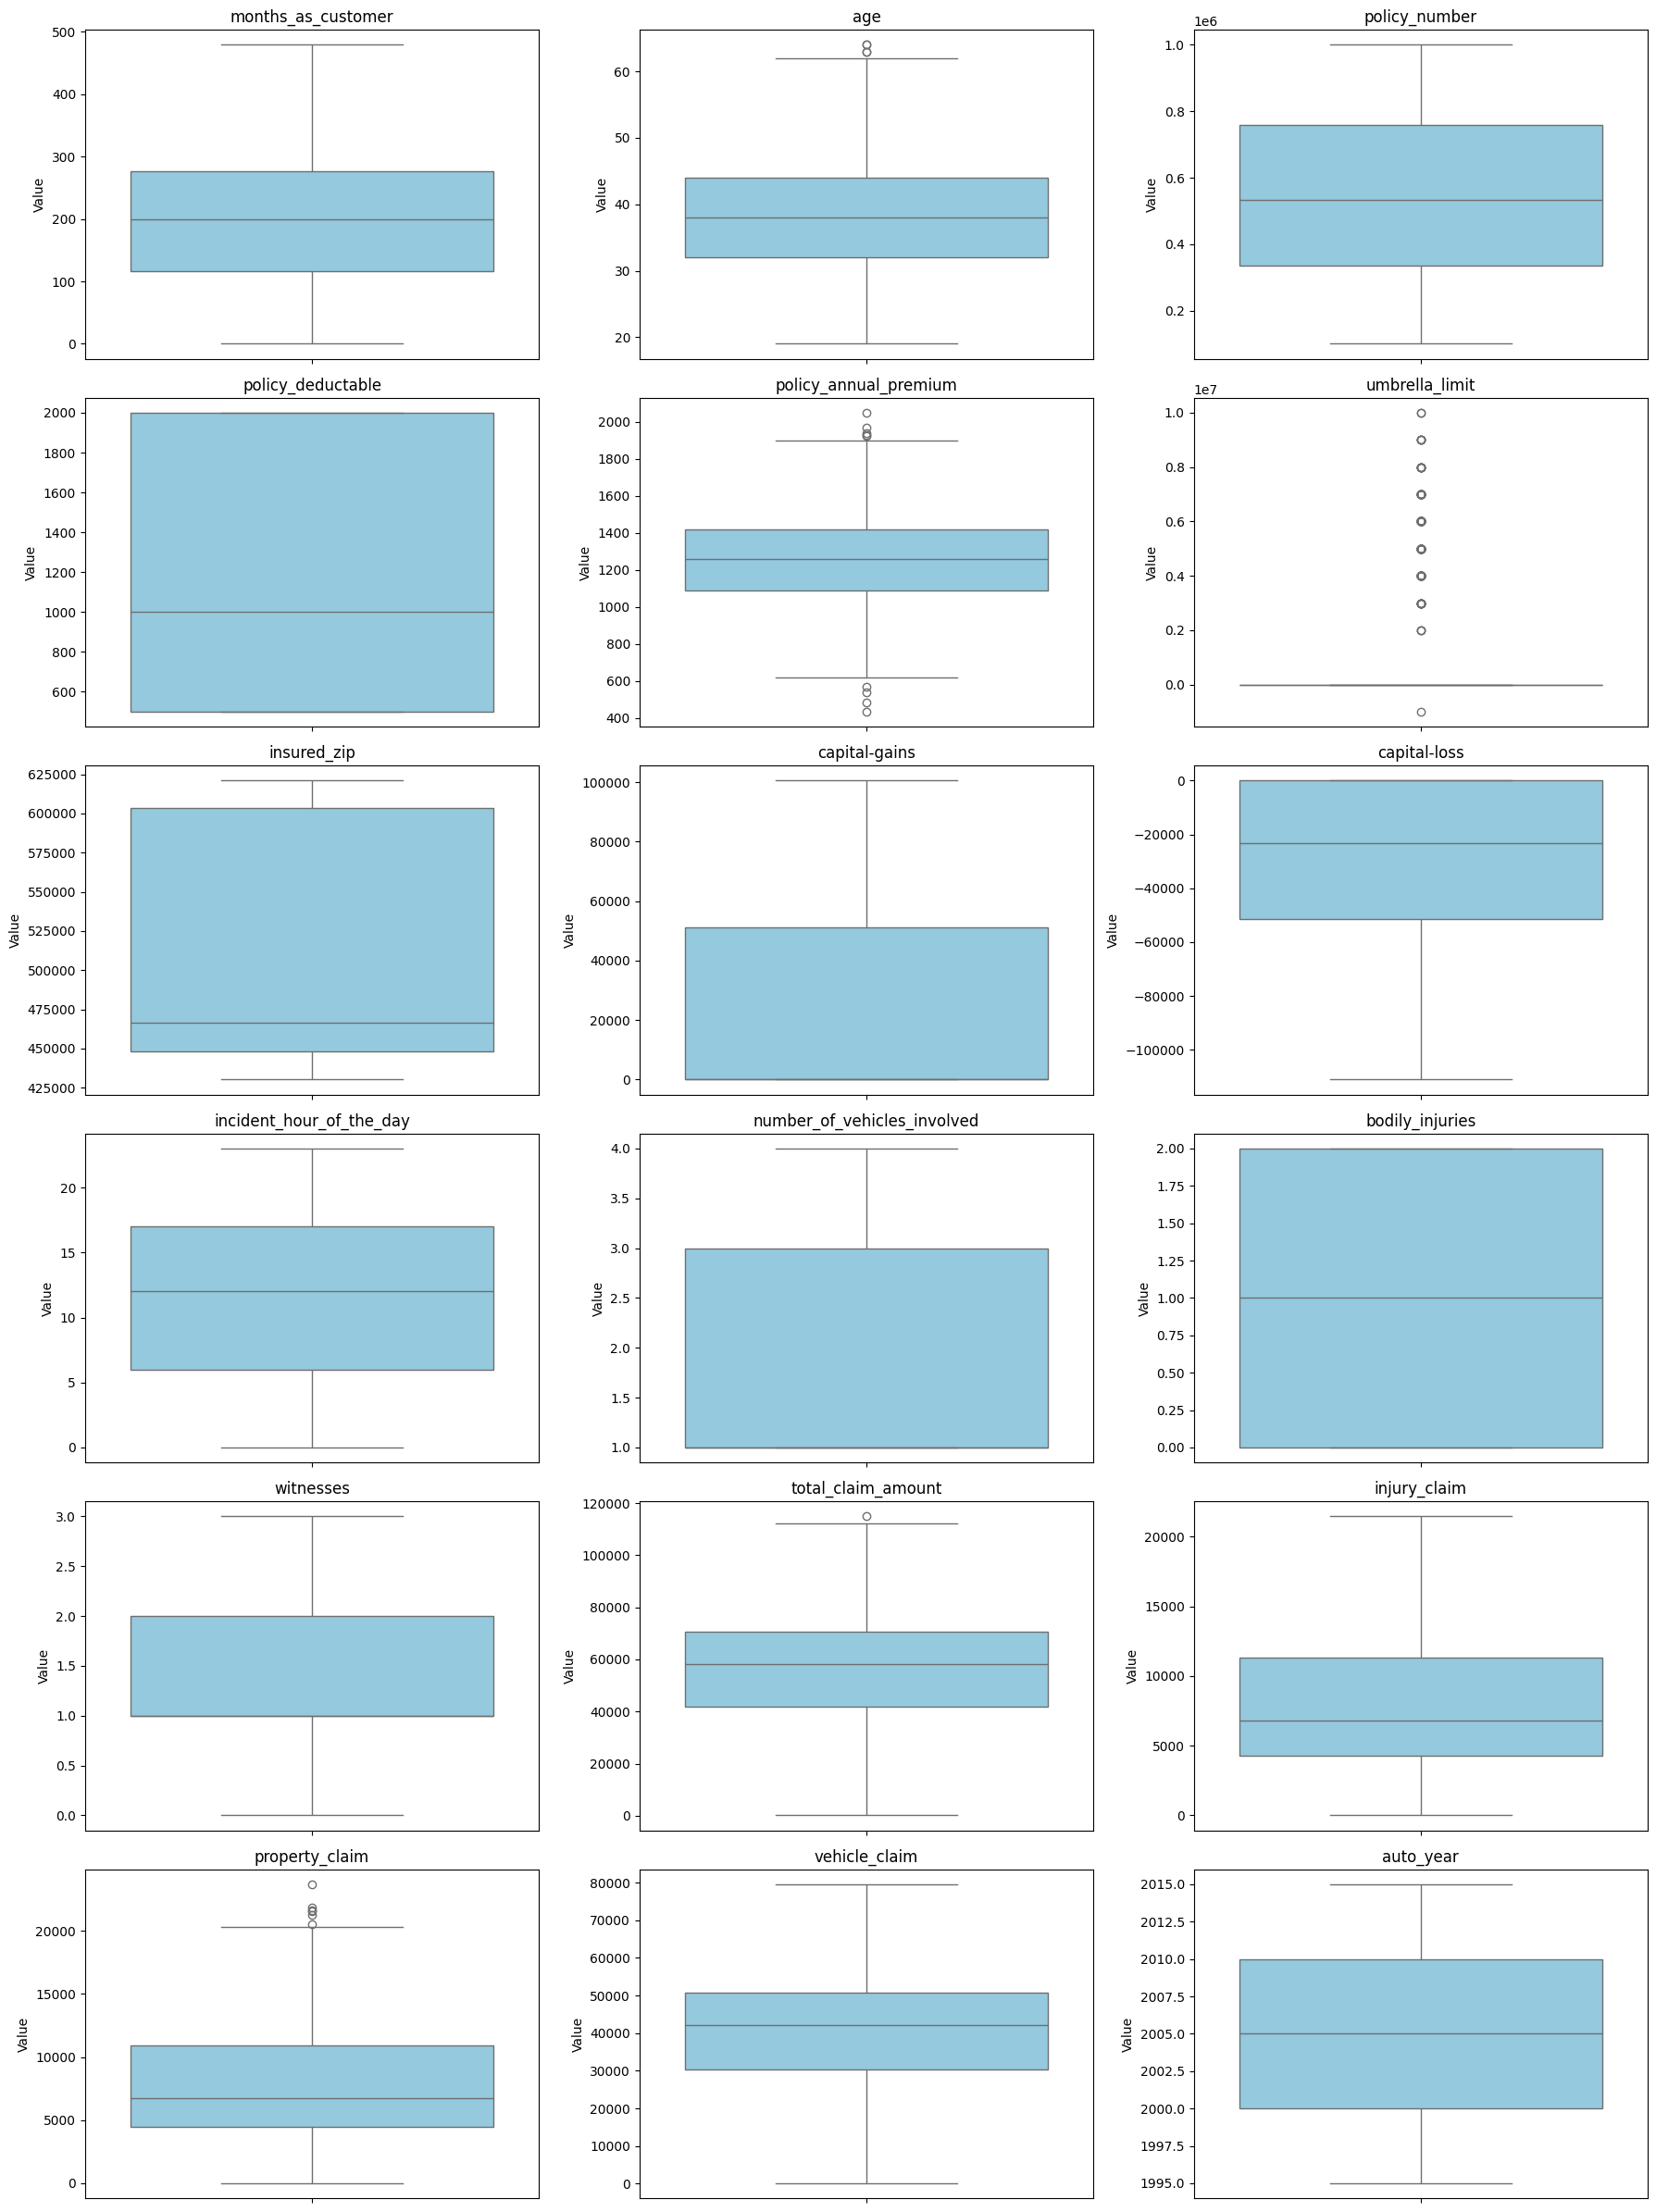

In [73]:
# Boxplots for all numerical columns
n_cols = 3
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).flatten()

for i, column in enumerate(numerical_columns):
    sns.boxplot(y=num_df[column], ax=axes[i], color="skyblue")
    axes[i].set_title(column)
    axes[i].set_ylabel("Value")

# Hide unused subplots
for ax in axes[len(numerical_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Nous remarquons la presence de outliers dans : 
- age 
-policy_annual_prenium
-property_claim
-umbrella limit 
-total_amount_claim


In [74]:
num_df.isnull().sum()

num_df.drop(columns=['umbrella_limit'], inplace=True, errors='ignore')

num_df.head(5)

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
0,328,48,521585,1000,1406.91,466132,53300,0,5,1,1,2,71610,6510,13020,52080,2004
1,228,42,342868,2000,1197.22,468176,0,0,8,1,0,0,5070,780,780,3510,2007
2,134,29,687698,2000,1413.14,430632,35100,0,7,3,2,3,34650,7700,3850,23100,2007
3,256,41,227811,2000,1415.74,608117,48900,-62400,5,1,1,2,63400,6340,6340,50720,2014
4,228,44,367455,1000,1583.91,610706,66000,-46000,20,1,0,1,6500,1300,650,4550,2009


In [75]:
cat_df.isnull().sum()

policy_state               0
policy_csl                 0
insured_sex                0
insured_education_level    0
insured_occupation         0
insured_hobbies            0
insured_relationship       0
incident_type              0
collision_type             0
incident_severity          0
authorities_contacted      0
incident_state             0
incident_city              0
incident_location          0
property_damage            0
police_report_available    0
auto_make                  0
auto_model                 0
fraud_reported             0
dtype: int64

In [76]:
cat_df['policy_csl'].unique()

array(['250/500', '100/300', '500/1000'], dtype=object)

In [77]:

cat_df_encoded = pd.get_dummies(cat_df, columns = ['auto_make','policy_state','incident_state','authorities_contacted','property_damage','police_report_available','incident_severity','incident_type', 'policy_csl', 'insured_education_level','collision_type', 'insured_sex'] , drop_first= False )   
 

In [78]:
cat_df_encoded

,insured_occupation,insured_hobbies,insured_relationship,incident_city,incident_location,auto_model,fraud_reported,auto_make_Accura,auto_make_Audi,auto_make_BMW,...,insured_education_level_JD,insured_education_level_MD,insured_education_level_Masters,insured_education_level_PhD,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,collision_type_Unknown collision,insured_sex_FEMALE,insured_sex_MALE
0,craft-repair,sleeping,husband,Columbus,9935 4th Drive,92x,Y,False,False,False,...,False,True,False,False,False,False,True,False,False,True
1,machine-op-inspct,reading,other-relative,Riverwood,6608 MLK Hwy,E400,Y,False,False,False,...,False,True,False,False,False,False,False,True,False,True
2,sales,board-games,own-child,Columbus,7121 Francis Lane,RAM,N,False,False,False,...,False,False,False,True,False,True,False,False,True,False
3,armed-forces,board-games,unmarried,Arlington,6956 Maple Drive,Tahoe,Y,False,False,False,...,False,False,False,True,True,False,False,False,True,False
4,sales,board-games,unmarried,Arlington,3041 3rd Ave,RSX,N,True,False,False,...,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,craft-repair,paintball,unmarried,Northbrook,6045 Andromedia St,Accord,N,False,False,False,...,False,False,True,False,True,False,False,False,True,False
996,prof-specialty,sleeping,wife,Northbend,3092 Texas Drive,Passat,N,False,False,False,...,False,False,False,True,False,True,False,False,True,False
997,armed-forces,bungie-jumping,other-relative,Arlington,7629 5th St,Impreza,N,False,False,False,...,False,False,True,False,False,False,True,False,True,False
998,handlers-cleaners,base-jumping,wife,Arlington,6128 Elm Lane,A5,N,False,True,False,...,False,False,False,False,False,True,False,False,False,True


In [79]:
df1 = num_df.join(cat_df_encoded)

In [80]:
df = df1.join(res_df)

In [81]:
df

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,...,insured_education_level_Masters,insured_education_level_PhD,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,collision_type_Unknown collision,insured_sex_FEMALE,insured_sex_MALE,policy_bind_date,incident_date
0,328,48,521585,1000,1406.91,466132,53300,0,5,1,...,False,False,False,False,True,False,False,True,2014-10-17,2015-01-25
1,228,42,342868,2000,1197.22,468176,0,0,8,1,...,False,False,False,False,False,True,False,True,2006-06-27,2015-01-21
2,134,29,687698,2000,1413.14,430632,35100,0,7,3,...,False,True,False,True,False,False,True,False,2000-09-06,2015-02-22
3,256,41,227811,2000,1415.74,608117,48900,-62400,5,1,...,False,True,True,False,False,False,True,False,1990-05-25,2015-01-10
4,228,44,367455,1000,1583.91,610706,66000,-46000,20,1,...,False,False,False,False,False,True,False,True,2014-06-06,2015-02-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1000,1310.80,431289,0,0,20,1,...,True,False,True,False,False,False,True,False,1991-07-16,2015-02-22
996,285,41,186934,1000,1436.79,608177,70900,0,23,1,...,False,True,False,True,False,False,True,False,2014-01-05,2015-01-24
997,130,34,918516,500,1383.49,442797,35100,0,4,3,...,True,False,False,False,True,False,True,False,2003-02-17,2015-01-23
998,458,62,533940,2000,1356.92,441714,0,0,2,1,...,False,False,False,True,False,False,False,True,2011-11-18,2015-02-26


In [82]:
df.drop(columns=['incident_hour_of_the_day','insured_hobbies','incident_location', 'auto_model', 'insured_occupation','insured_relationship','incident_city'], inplace=True, errors='ignore')

In [83]:
df

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,insured_zip,capital-gains,capital-loss,number_of_vehicles_involved,bodily_injuries,...,insured_education_level_Masters,insured_education_level_PhD,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,collision_type_Unknown collision,insured_sex_FEMALE,insured_sex_MALE,policy_bind_date,incident_date
0,328,48,521585,1000,1406.91,466132,53300,0,1,1,...,False,False,False,False,True,False,False,True,2014-10-17,2015-01-25
1,228,42,342868,2000,1197.22,468176,0,0,1,0,...,False,False,False,False,False,True,False,True,2006-06-27,2015-01-21
2,134,29,687698,2000,1413.14,430632,35100,0,3,2,...,False,True,False,True,False,False,True,False,2000-09-06,2015-02-22
3,256,41,227811,2000,1415.74,608117,48900,-62400,1,1,...,False,True,True,False,False,False,True,False,1990-05-25,2015-01-10
4,228,44,367455,1000,1583.91,610706,66000,-46000,1,0,...,False,False,False,False,False,True,False,True,2014-06-06,2015-02-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1000,1310.80,431289,0,0,1,0,...,True,False,True,False,False,False,True,False,1991-07-16,2015-02-22
996,285,41,186934,1000,1436.79,608177,70900,0,1,2,...,False,True,False,True,False,False,True,False,2014-01-05,2015-01-24
997,130,34,918516,500,1383.49,442797,35100,0,3,2,...,True,False,False,False,True,False,True,False,2003-02-17,2015-01-23
998,458,62,533940,2000,1356.92,441714,0,0,1,0,...,False,False,False,True,False,False,False,True,2011-11-18,2015-02-26


In [84]:
df.select_dtypes(include='object').nunique()

fraud_reported    2
dtype: int64

C'est une classification binaire :

0 → N
1 → Y


In [85]:
df["fraud_reported"] = df["fraud_reported"].map({
    "N": 0,
    "Y": 1
})

In [86]:
df


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,insured_zip,capital-gains,capital-loss,number_of_vehicles_involved,bodily_injuries,...,insured_education_level_Masters,insured_education_level_PhD,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,collision_type_Unknown collision,insured_sex_FEMALE,insured_sex_MALE,policy_bind_date,incident_date
0,328,48,521585,1000,1406.91,466132,53300,0,1,1,...,False,False,False,False,True,False,False,True,2014-10-17,2015-01-25
1,228,42,342868,2000,1197.22,468176,0,0,1,0,...,False,False,False,False,False,True,False,True,2006-06-27,2015-01-21
2,134,29,687698,2000,1413.14,430632,35100,0,3,2,...,False,True,False,True,False,False,True,False,2000-09-06,2015-02-22
3,256,41,227811,2000,1415.74,608117,48900,-62400,1,1,...,False,True,True,False,False,False,True,False,1990-05-25,2015-01-10
4,228,44,367455,1000,1583.91,610706,66000,-46000,1,0,...,False,False,False,False,False,True,False,True,2014-06-06,2015-02-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1000,1310.80,431289,0,0,1,0,...,True,False,True,False,False,False,True,False,1991-07-16,2015-02-22
996,285,41,186934,1000,1436.79,608177,70900,0,1,2,...,False,True,False,True,False,False,True,False,2014-01-05,2015-01-24
997,130,34,918516,500,1383.49,442797,35100,0,3,2,...,True,False,False,False,True,False,True,False,2003-02-17,2015-01-23
998,458,62,533940,2000,1356.92,441714,0,0,1,0,...,False,False,False,True,False,False,False,True,2011-11-18,2015-02-26


In [87]:
df.select_dtypes(include="datetime").columns

Index(['policy_bind_date', 'incident_date'], dtype='object')

In [88]:
df["policy_bind_year"] = df["policy_bind_date"].dt.year
df["policy_bind_month"] = df["policy_bind_date"].dt.month

df["incident_year"] = df["incident_date"].dt.year
df["incident_month"] = df["incident_date"].dt.month

In [89]:
df.drop(
    columns=["policy_bind_date", "incident_date"],
    inplace=True
)

In [90]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [91]:
df.select_dtypes(include="datetime").columns

Index([], dtype='object')

In [92]:
df.isna().sum().sum()

np.int64(0)

In [93]:
df

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,insured_zip,capital-gains,capital-loss,number_of_vehicles_involved,bodily_injuries,...,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,collision_type_Unknown collision,insured_sex_FEMALE,insured_sex_MALE,policy_bind_year,policy_bind_month,incident_year,incident_month
0,328,48,521585,1000,1406.91,466132,53300,0,1,1,...,False,False,True,False,False,True,2014,10,2015,1
1,228,42,342868,2000,1197.22,468176,0,0,1,0,...,False,False,False,True,False,True,2006,6,2015,1
2,134,29,687698,2000,1413.14,430632,35100,0,3,2,...,False,True,False,False,True,False,2000,9,2015,2
3,256,41,227811,2000,1415.74,608117,48900,-62400,1,1,...,True,False,False,False,True,False,1990,5,2015,1
4,228,44,367455,1000,1583.91,610706,66000,-46000,1,0,...,False,False,False,True,False,True,2014,6,2015,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1000,1310.80,431289,0,0,1,0,...,True,False,False,False,True,False,1991,7,2015,2
996,285,41,186934,1000,1436.79,608177,70900,0,1,2,...,False,True,False,False,True,False,2014,1,2015,1
997,130,34,918516,500,1383.49,442797,35100,0,3,2,...,False,False,True,False,True,False,2003,2,2015,1
998,458,62,533940,2000,1356.92,441714,0,0,1,0,...,False,True,False,False,False,True,2011,11,2015,2


In [94]:
X = df.drop(columns=['fraud_reported'])

y = df['fraud_reported']

X = ce que le modèle voit
y = ce que le modèle doit prédire

X_train = données utilisées pour apprendre
y_train = réponses utilisées pour apprendre

X_test = données jamais utilisées pour apprendre
y_test = vraies réponses servant à évaluer le modèle

test_size=0.2 = 20% pour le test

random_state=42 = même séparation à chaque exécution

stratify=y = conserver la proportion des classes


"Prends mes variables explicatives X et ma variable cible y, sépare-les aléatoirement en 80 % pour l'entraînement et 20 % pour le test, utilise une séparation reproductible avec random_state=42, et conserve la même proportion des classes de y dans les deux ensembles."

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [96]:
y.value_counts(normalize=True)

fraud_reported
0    0.753
1    0.247
Name: proportion, dtype: float64

Scaling data : - mettre les variables numeriques sur meme echelle 

using here RobustScaler() - so Ce choix est cohérent avec ton analyse précédente des outliers.

RobustScaler utilise principalement :

la médiane
l'IQR (Interquartile Range)

plutôt que la moyenne et l'écart-type.

Donc il est moins sensible aux valeurs extrêmes que StandardScaler.

Mais attention :

RobustScaler ne supprime pas les outliers.

Il réduit simplement leur influence sur le scaling.



*fit_transform() : calcule les parametres des donnees (comme la moyenne et la variance) et les transformes en une seule etape.
      cette methode s'utilise sur les donnes d'entrainement uniquement (X_train)


     en effet, - fit () : apprend les parametres, elle calcule les statistiques sous jacentes du jeu de donnes, elle enregistre ces valeurs en memoire. cette methode ne modifie pas les donnes 
                
                -transform(): applique les parametres, elle utilse les statistiques calculees par le fit() precedent pour modifier et transformer le jeu de donnees 

    

*transform(): applique uniquement ces parametres deja appris a de nouvelles donnes sans rien calculer 
             utliser principalement sur les donnes de validation / production (X_test )


Remark : - NE JAMAIS UTILISER fit_transform() SUR LES DONNES DE TEST
             Utiliser fit_transform sur votre jeu de données de test provoque une erreur grave appelée fuite de données (data leakage).Vos données de test sont censées simuler des données futures et "inconnues". Si vous appliquez fit_transform sur le jeu de test, le transformateur va calculer une nouvelle moyenne et une nouvelle variance propres au jeu de test. Votre modèle va alors tricher en s'adaptant à la distribution des données de test. Cela faussera vos évaluations en vous donnant des scores artificiellement élevés qui s'effondreront en conditions réelles.





In [97]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


"""Pourquoi fit seulement sur X_train ?

Parce que le modèle doit fonctionner comme dans la vraie vie :

DONNÉES DISPONIBLES
       ↓
   X_train
       ↓
calcul du scaling
       ↓
apprentissage
       ↓
      modèle
       ↓
X_test → données inconnues

Le modèle ne doit jamais apprendre quelque chose à partir du test avant son évaluation."""

'Pourquoi fit seulement sur X_train ?\n\nParce que le modèle doit fonctionner comme dans la vraie vie :\n\nDONNÉES DISPONIBLES\n       ↓\n   X_train\n       ↓\ncalcul du scaling\n       ↓\napprentissage\n       ↓\n      modèle\n       ↓\nX_test → données inconnues\n\nLe modèle ne doit jamais apprendre quelque chose à partir du test avant son évaluation.'

Avec class_weight="balanced" 

Au lieu de modifier physiquement ton dataset, le modèle donne davantage d'importance à la classe minoritaire.

In [98]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

.TP --->True Positive : le model predit 1 et la realite est 1 (le model a correctement detecte la panne)

.TN --->True Negative : le model predit 0 et la realite est 0 ( le model a correctement identifie le moteur normal)

.FP --->False Positive : le model predit 1 et la realite est 0 (le model declenche une fausse alerte)

.FN --->False Negative : le model predit 0 et la realite est 0(le model rate une vraie panne )



Confusion matrix :
                         (0)                             (1)
                   Realite = Normal               Realite = Panne

     (0)
Predit = Normal           TN                           FN

     (1)
Predit = Panne            FP                           TP




.Precision : lorsque mon model dit "Panne" EST CE VRAIMENT UNE PANNE ?
    Exple:   On a : TP + FP = 3 + 2 = 5 
             Donc sur 5 predictions , 3 etaient vraiment des pannes et 2 etaient de fausses alertes 

             precision = TP / (TP + FP) = 60% ---> Donc quand le model dit panne, il a raison 60% du temps 

  Precision regarde ce que le model a predit comme PANNE , il demande << est ce que mes alertes sont correctes>>  il regarde particulieremnet les FP  


  Avec precison ---> quand de declare je declare quelque comme etant j'ai raison a combien de fois         
                    EST CE QUE MES ALERTES SONT CORRECTES  LEUR POIURCENTAGE 
                    SUR CE QU'IL A IDENTIFIE COMME PANNES COMBIEN SONT VRAIES / VRAIMENT DES PANNES 


.Recall : parmi toutes les vraies pannes, combien mon modeles a t il detectes 
        on a : TP + FN 
            = 3 + 1 
            =  4 vraies pannes 

            le modele a detecter TP = 3 DONC 

            RECALL = TP / (TP + FN ) = 3 / (3 +1 )  = 75%    


        TP ( LES PANNES QUE  MON MODEL A TROUVE ) + FN (LES PANNES EXISTANTES  QUE MON MODEL A RATE  )   = TOUTE LES PANNES EXISTANTES 

        DONC AVEC RECALL : SUR TOUTE LES PANNES EXISTANTES, MON MODEL ARRIVE A DETECTE / TROUVER COMBIEN 





.F-1 SCORE : On a Precison et Recall 
              
              on aimerait avoir une valeur qui combien les deux 

              f1 = 2 * [(Precision * Recall) / (Precision + Recall) ]




*Accuracy score : Globalement combien de mes predictions sont correctes 
                  Toutes les predictions 

            - 





           


             

In [99]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 
from sklearn.metrics import confusion_matrix



y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1-Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.79      0.85       151
           1       0.54      0.73      0.62        49

    accuracy                           0.78       200
   macro avg       0.72      0.76      0.73       200
weighted avg       0.81      0.78      0.79       200

Accuracy: 0.78
Precision: 0.5373134328358209
Recall: 0.7346938775510204
F1-Score: 0.6206896551724138
Confusion Matrix:
[[120  31]
 [ 13  36]]


In [100]:
from sklearn.svm import SVC

model_1 = SVC(
    class_weight="balanced",
    random_state=42,
    max_iter=-1
)

model_1.fit(X_train_scaled, y_train)


y_pred_1 = model_1.predict(X_test_scaled)

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
 
print(classification_report(y_test, y_pred_1))
print("Accuracy:", accuracy_score(y_test, y_pred_1))
print("Precision:", precision_score(y_test, y_pred_1))  
print("Recall:", recall_score(y_test, y_pred_1))
print("F1-Score:", f1_score(y_test, y_pred_1))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1))


              precision    recall  f1-score   support

           0       0.91      0.85      0.88       151
           1       0.62      0.73      0.67        49

    accuracy                           0.82       200
   macro avg       0.76      0.79      0.78       200
weighted avg       0.84      0.82      0.83       200

Accuracy: 0.825
Precision: 0.6206896551724138
Recall: 0.7346938775510204
F1-Score: 0.6728971962616822
Confusion Matrix:
[[129  22]
 [ 13  36]]


## Conclusion sur la performance du modèle

Le modèle obtient une accuracy de 82.5 %.

Pour la classe « fraude », il obtient une precision de 62 % :
parmi les dossiers signalés comme potentiellement frauduleux, 62 % sont réellement des fraudes.

Le recall de 73.4% signifie que le modèle détecte 73.4 % des fraudes réelles,
mais laisse passer 26.6 % d’entre elles.

Dans un contexte de détection de fraude, le recall est prioritaire,
car il est important de réduire le nombre de fraudes non détectées.
Cependant, une precision trop faible créerait trop de fausses alertes
et augmenterait la charge de travail des enquêteurs.

Le modèle doit donc être utilisé comme un outil de priorisation des
dossiers à vérifier, et non comme une décision automatique de fraude.

le best performing modelis svc with presenting an efficient recall

In [101]:
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_estimators=100
)

model_2.fit(X_train_scaled, y_train)

y_pred_2 = model_2.predict(X_test_scaled)
print(classification_report(y_test, y_pred_2))
print("Accuracy:", accuracy_score(y_test, y_pred_2))
print("Precision:", precision_score(y_test, y_pred_2))
print("Recall:", recall_score(y_test, y_pred_2))
print("F1-Score:", f1_score(y_test, y_pred_2))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_2))


              precision    recall  f1-score   support

           0       0.81      0.94      0.87       151
           1       0.62      0.31      0.41        49

    accuracy                           0.79       200
   macro avg       0.72      0.62      0.64       200
weighted avg       0.76      0.79      0.76       200

Accuracy: 0.785
Precision: 0.625
Recall: 0.30612244897959184
F1-Score: 0.410958904109589
Confusion Matrix:
[[142   9]
 [ 34  15]]


In [103]:
#comparaison finale des modèles

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVC",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_1),
        accuracy_score(y_test, y_pred_2)
    ],
    "Precision fraud": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_1),
        precision_score(y_test, y_pred_2)
    ],
    "Recall fraud": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_1),
        recall_score(y_test, y_pred_2)
    ],
    "F1-score fraud": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_1),
        f1_score(y_test, y_pred_2)
    ]
})

comparison

,Model,Accuracy,Precision fraud,Recall fraud,F1-score fraud
0,Logistic Regression,0.780,0.537313,0.734694,0.620690
1,SVC,0.825,0.620690,0.734694,0.672897
2,Random Forest,0.785,0.625000,0.306122,0.410959


## Modèle final sélectionné

Trois modèles ont été comparés : Logistic Regression, SVC et Random Forest.

Le modèle SVC est retenu comme modèle final. Il présente le même recall que Logistic Regression, tout en obtenant une meilleure precision, un meilleur F1-score et une meilleure accuracy.

Le modèle détecte 36 fraudes sur 49 dans les données de test, soit un recall de 73,5 %. Il génère 22 fausses alertes sur 200 dossiers de test.

Ce modèle est utile pour prioriser les dossiers nécessitant une investigation humaine. Il ne doit pas être utilisé pour prendre automatiquement une décision de fraude.

In [104]:
#choisir officiellement le modèle
best_model = model_1
best_model_name = "SVC"

print("Modèle final :", best_model_name)

Modèle final : SVC


In [105]:
#créer le dossier de sauvegarde
from pathlib import Path
import joblib

PROJECT_DIR = Path(
    r"C:\Users\Martino VIGNIGBE\OneDrive\DATA SCIENCE PROJECT MARTINO\insurance-fraud-detection"
)

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "insurance_fraud_model.joblib"

print(MODEL_PATH)

C:\Users\Martino VIGNIGBE\OneDrive\DATA SCIENCE PROJECT MARTINO\insurance-fraud-detection\models\insurance_fraud_model.joblib


In [106]:
#sauvegarder le modèle final
model_artifact = {
    "model": best_model,
    "scaler": scaler,
    "feature_names": X.columns.tolist(),
    "model_name": best_model_name
}

joblib.dump(model_artifact, MODEL_PATH)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


In [107]:
#vérifier le rechargement
loaded_artifact = joblib.load(MODEL_PATH)

print("Modèle rechargé :", loaded_artifact["model_name"])
print("Nombre de variables attendues :",
      len(loaded_artifact["feature_names"]))

Modèle rechargé : SVC
Nombre de variables attendues : 78


In [108]:
#prédiction de vérification
loaded_model = loaded_artifact["model"]
loaded_scaler = loaded_artifact["scaler"]

sample_claim = X_test.iloc[[0]]

sample_claim_scaled = loaded_scaler.transform(sample_claim)

prediction = loaded_model.predict(sample_claim_scaled)[0]

print("Prédiction du modèle :", prediction)
print("Valeur réelle :", y_test.iloc[0])

Prédiction du modèle : 0
Valeur réelle : 0


Mon modèle actuel reçoit des données déjà préparées : catégories encodées, dates transformées et données scalées. Donc, pour une première application fiable, l’application analysera un fichier CSV de variables préparées. Elle ne demandera pas encore à l’utilisateur de remplir les 30+ informations brutes d’une déclaration.

In [109]:
FEATURES_PATH = PROJECT_DIR / "data" / "processed_claim_features.csv"

X.to_csv(FEATURES_PATH, index=False)

print("Fichier créé :")
print(FEATURES_PATH)

Fichier créé :
C:\Users\Martino VIGNIGBE\OneDrive\DATA SCIENCE PROJECT MARTINO\insurance-fraud-detection\data\processed_claim_features.csv
